# Section views PDF generator

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

df = pd.read_csv('CSV_combined/combined.csv', names=['posX', 'posY', 'posZ', 'A', 'B', 'C', 'Z'])

df2 = df.round(decimals=0)
df2.drop_duplicates(subset=['posX', 'posY', 'posZ'], keep='last',inplace=True)


# hardcoded value (129) will slice 129 X section views starting at xyz 0,-320,0.
for i in range(129):
    pos = (i*5)-320

    # specific xyz positions can be used to generate individual section views in the PDF if the "for i in range(129):" loop is removed
    posX = pos
    posY = pos
    # since we only map 230mm in height, we just "reuse" the highest layer for xy over 230mm to show "something" for the z section view in those pages
    if i < 23:
        posZ = pos
    else:
        posZ = 230

    df3 = df2.loc[(df2['posX'] > posX-1) & (df2['posX'] < posX+1)]
    df4 = df2.loc[(df2['posY'] > posY-1) & (df2['posY'] < posY+1)]
    df5 = df2.loc[(df2['posZ'] == posZ)]
    df5 = df5.round(decimals=0)
    df5.drop_duplicates(subset=['posX', 'posY', 'posZ'], keep='last',inplace=True)

    # quick setup of the plots. Everything related to the plots could have been done better... 
    fig = make_subplots(rows=1, cols=4, subplot_titles=(
#            'Sensor A, Y section view, X position: '+ str(posX) + 'mm', 
#            'Sensor B, Y section view, X position: '+ str(posX) + 'mm', 
#            'Sensor C, Y section view, X position: '+ str(posX) + 'mm', 
#            'Sensor Z, Y section view, X position: '+ str(posX) + 'mm', 
            'Sensor A, X section view, Y position: '+ str(posY) + 'mm', 
            'Sensor B, X section view, Y position: '+ str(posY) + 'mm', 
            'Sensor C, X section view, Y position: '+ str(posY) + 'mm', 
            'Sensor Z, X section view, Y position: '+ str(posY) + 'mm' 
#            'Sensor A, Z section view, Z position: '+ str(posZ) + 'mm', 
#            'Sensor B, Z section view, Z position: '+ str(posZ) + 'mm', 
#            'Sensor C, Z section view, Z position: '+ str(posZ) + 'mm', 
#            'Sensor Z, Z section view, Z position: '+ str(posZ) + 'mm'
        )
    )

    Zebra = [
                [0.0, "rgb(0, 0, 0)"],
                [0.0285714285714286, "rgb(255,255,255)"],
                [0.0571428571428571, "rgb(0,0,0)"],
                [0.0857142857142857, "rgb(255,255,255)"],
                [0.114285714285714, "rgb(0,0,0)"],
                [0.142857142857143, "rgb(255,255,255)"],
                [0.171428571428571, "rgb(0,0,0)"],
                [0.2, "rgb(255,255,255)"],
                [0.228571428571429, "rgb(0,0,0)"],
                [0.257142857142857, "rgb(255,255,255)"],
                [0.285714285714286, "rgb(0,0,0)"],
                [0.314285714285714, "rgb(255,255,255)"],
                [0.342857142857143, "rgb(0,0,0)"],
                [0.371428571428571, "rgb(255,255,255)"],
                [0.4, "rgb(0,0,0)"],
                [0.428571428571429, "rgb(255,255,255)"],
                [0.457142857142857, "rgb(0,0,0)"],
                [0.485714285714286, "rgb(255,255,255)"],
                [0.514285714285714, "rgb(0,0,0)"],
                [0.542857142857143, "rgb(255,255,255)"],
                [0.571428571428571, "rgb(0,0,0)"],
                [0.6, "rgb(255,255,255)"],
                [0.628571428571429, "rgb(0,0,0)"],
                [0.657142857142857, "rgb(255,255,255)"],
                [0.685714285714286, "rgb(0,0,0)"],
                [0.714285714285714, "rgb(255,255,255)"],
                [0.742857142857143, "rgb(0,0,0)"],
                [0.771428571428571, "rgb(255,255,255)"],
                [0.8, "rgb(0,0,0)"],
                [0.828571428571429, "rgb(255,255,255)"],
                [0.857142857142857, "rgb(0,0,0)"],
                [0.885714285714286, "rgb(255,255,255)"],
                [0.914285714285714, "rgb(0,0,0)"],
                [0.942857142857143, "rgb(255,255,255)"],
                [0.971428571428571, "rgb(0,0,0)"],
                [1, "rgb(255,255,255)"]]

    # choose color palette to be used. Comment out the one not to be used
    ColPal = 'Viridis'
    #ColPal = Zebra

#    fig.add_trace(
#        go.Heatmap(
#            x=df3['posY'], y=df3['posZ'], z=df3['A'],
#            colorscale=ColPal, 
#            zmin=0, zmax=35000, connectgaps=True, zsmooth='best'), 1, 1
#    )
#
#    fig.add_trace(
#        go.Heatmap(
#            x=df3['posY'], y=df3['posZ'], z=df3['B'],
#            colorscale=ColPal, 
#            zmin=0, zmax=35000, connectgaps=True, zsmooth='best'), 1, 2
#    )
#
#    fig.add_trace(
#        go.Heatmap(
#            x=df3['posY'], y=df3['posZ'], z=df3['C'],
#            colorscale=ColPal, 
#            zmin=0, zmax=35000, connectgaps=True, zsmooth='best'), 1, 3
#    )
#
#    fig.add_trace(
#        go.Heatmap(
#            x=df3['posY'], y=df3['posZ'], z=df3['Z'],
#            colorscale=ColPal, 
#            zmin=0, zmax=35000, connectgaps=True, zsmooth='best'), 1, 4
#    )
#
    fig.add_trace(
        go.Heatmap(
            x=df4['posX'], y=df4['posZ'], z=df4['A'],
            colorscale=ColPal, 
            zmin=0, zmax=35000, connectgaps=True, zsmooth='best'), 1, 1
    )

    fig.add_trace(
        go.Heatmap(
            x=df4['posX'], y=df4['posZ'], z=df4['B'],
            colorscale=ColPal, 
            zmin=0, zmax=35000, connectgaps=True, zsmooth='best'), 1, 2
    )

    fig.add_trace(
        go.Heatmap(
            x=df4['posX'], y=df4['posZ'], z=df4['C'],
            colorscale=ColPal, 
            zmin=0, zmax=35000, connectgaps=True, zsmooth='best'), 1, 3
    )

    fig.add_trace(
        go.Heatmap(
            x=df4['posX'], y=df4['posZ'], z=df4['Z'],
            colorscale=ColPal, 
            zmin=0, zmax=35000, connectgaps=True, zsmooth='best'), 1, 4
    )
#
#    fig.add_trace(
#        go.Heatmap(
#            x=df5['posX'], y=df5['posY'], z=df5['A'],
#            colorscale=ColPal, 
#            zmin=0, zmax=35000, connectgaps=True, zsmooth='best'), 3, 1
#    )
#
#    fig.add_trace(
#        go.Heatmap(
#            x=df5['posX'], y=df5['posY'], z=df5['B'],
#            colorscale=ColPal, 
#            zmin=0, zmax=35000, connectgaps=True, zsmooth='best'), 3, 2
#    )
#
#    fig.add_trace(
#        go.Heatmap(
#            x=df5['posX'], y=df5['posY'], z=df5['C'],
#            colorscale=ColPal, 
#            zmin=0, zmax=35000, connectgaps=True, zsmooth='best'), 3, 3
#    )
#
#    fig.add_trace(
#        go.Heatmap(
#            x=df5['posX'], y=df5['posY'], z=df5['Z'],
#            colorscale=ColPal, 
#            zmin=0, zmax=35000, connectgaps=True, zsmooth='best'), 3, 4
#    )

    fig.update_layout(
        title='Magnetic homing – section views created from all XZ point samples at position Y:'+ str(posY) + 'mm',
#        yaxis1=dict(title_text="Z-axis", tickmode="array"),
#        yaxis2=dict(title_text="Z-axis", tickmode="array"),
#        yaxis3=dict(title_text="Z-axis", tickmode="array"),
#        yaxis4=dict(title_text="Z-axis", tickmode="array"),
        yaxis5=dict(title_text="Z-axis", tickmode="array"),
        yaxis6=dict(title_text="Z-axis", tickmode="array"),
        yaxis7=dict(title_text="Z-axis", tickmode="array"),
        yaxis8=dict(title_text="Z-axis", tickmode="array"),
#        yaxis9=dict(title_text="Y-axis", tickmode="array"),
#        yaxis10=dict(title_text="Y-axis", tickmode="array"),
#        yaxis11=dict(title_text="Y-axis", tickmode="array"),    
#        yaxis12=dict(title_text="Y-axis", tickmode="array"),

#        xaxis1=dict(title_text="Y-axis", tickmode="array"),
#        xaxis2=dict(title_text="Y-axis", tickmode="array"),
#        xaxis3=dict(title_text="Y-axis", tickmode="array"),
#        xaxis4=dict(title_text="Y-axis", tickmode="array"),
        xaxis5=dict(title_text="X-axis", tickmode="array"),
        xaxis6=dict(title_text="X-axis", tickmode="array"),
        xaxis7=dict(title_text="X-axis", tickmode="array"),
        xaxis8=dict(title_text="X-axis", tickmode="array")
#        xaxis9=dict(title_text="X-axis", tickmode="array"),
#        xaxis10=dict(title_text="X-axis", tickmode="array"),
#        xaxis11=dict(title_text="X-axis", tickmode="array"),    
#        xaxis12=dict(title_text="X-axis", tickmode="array")    
    )
    
    # uncomment lines below if you want to generate something else than the PDF(s). Note: remove for loop if you intend to show/save in one of the other formats below
    #fig.show(renderer="png")
    #fig.write_html("section_views.html")
    #fig.write_image("sectionviews.svg")
    #fig.show(renderer="svg", width=1600, height=1200)

    print('Generating file: Section_views-X' + str(posX) + '-Y' + str(posY) + '-Z' + str(posZ) + '.pdf')
    fig.write_image('Section_views-X' + str(posX) + '-Y' + str(posY) + '-Z' + str(posZ) + '.pdf', width=4800, height=460)
print('Finished')

Generating file: Section_views-X-320-Y-320-Z-320.pdf
Generating file: Section_views-X-315-Y-315-Z-315.pdf
Generating file: Section_views-X-310-Y-310-Z-310.pdf
Generating file: Section_views-X-305-Y-305-Z-305.pdf
Generating file: Section_views-X-300-Y-300-Z-300.pdf
Generating file: Section_views-X-295-Y-295-Z-295.pdf
Generating file: Section_views-X-290-Y-290-Z-290.pdf
Generating file: Section_views-X-285-Y-285-Z-285.pdf
Generating file: Section_views-X-280-Y-280-Z-280.pdf
Generating file: Section_views-X-275-Y-275-Z-275.pdf
Generating file: Section_views-X-270-Y-270-Z-270.pdf
Generating file: Section_views-X-265-Y-265-Z-265.pdf
Generating file: Section_views-X-260-Y-260-Z-260.pdf
Generating file: Section_views-X-255-Y-255-Z-255.pdf
Generating file: Section_views-X-250-Y-250-Z-250.pdf
Generating file: Section_views-X-245-Y-245-Z-245.pdf
Generating file: Section_views-X-240-Y-240-Z-240.pdf
Generating file: Section_views-X-235-Y-235-Z-235.pdf
Generating file: Section_views-X-230-Y-230-Z-2

,PosX,PosY,PosZ,A,B,C,Z
1836265,432.0,320.0,230.0,296,478,942,12
1836284,392.0,320.0,230.0,302,530,1034,12
1836285,390.0,320.0,230.0,298,572,1060,12
1836314,330.0,320.0,230.0,296,704,1192,12
1836322,312.0,320.0,230.0,340,762,1240,12
...,...,...,...,...,...,...,...
5043192,-443.0,-305.0,230.0,1038,450,352,12
5043193,-445.0,-305.0,230.0,1028,460,356,13
5043194,-447.0,-305.0,230.0,1010,436,350,12
5046817,-449.0,-305.0,230.0,1022,430,368,13


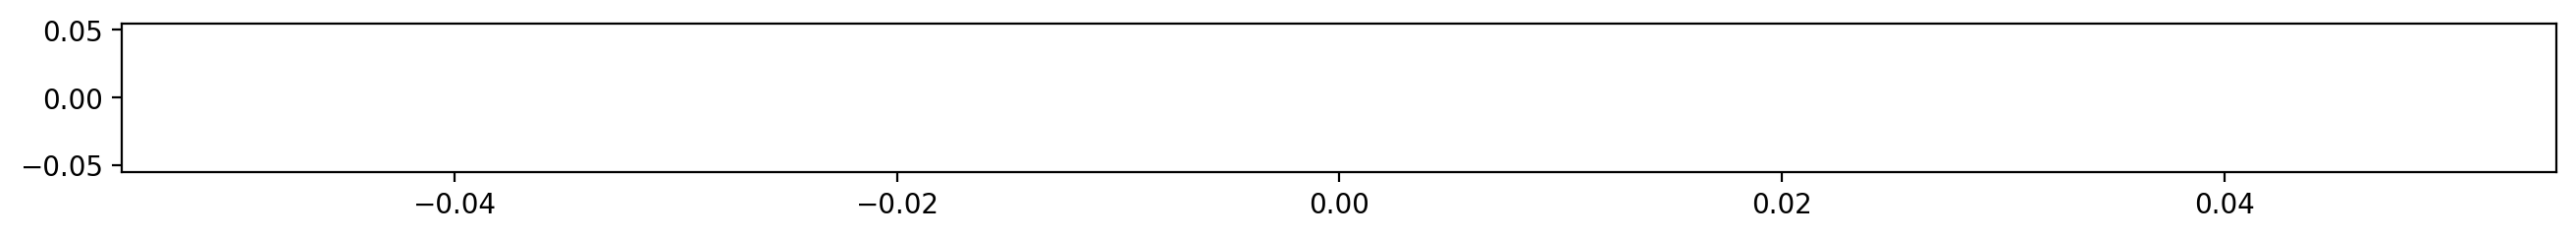

In [2]:
plt.figure(figsize=(16, 1), dpi=(200))
plt.scatter(df4['PosX'], df4['PosZ'], c=df4['C'], s=0.1, edgecolors='none', cmap = 'viridis', vmin=0, vmax=35000)
plt.savefig('combinedY.png', dpi=2400)

df5